# Clustering

## Wine Group Discovery

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

## 1. Load Cleaned Dataset

In [2]:
data_path = Path('../data/processed/winequality_cleaned.csv')
plot_dir = Path('../plots/clustering')
plot_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (1019, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


## 2. Prepare Features for Clustering

In [3]:
X = df.drop(columns='quality')
y = df['quality']

print(f'Feature matrix shape: {X.shape}')
display(X.head())

Feature matrix shape: (1019, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4


## 3. Feature Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Select Number of Clusters

In [5]:
k_values = list(range(2, 7))
clustering_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, cluster_labels)
    clustering_results.append({
        'k': k,
        'inertia': inertia,
        'silhouette_score': silhouette
    })

results_df = pd.DataFrame(clustering_results)
display(results_df)

,k,inertia,silhouette_score
0,2,9151.266960,0.185355
1,3,8020.076260,0.155737
2,4,7191.861916,0.162268
3,5,6658.010477,0.158604
4,6,6312.768677,0.151005


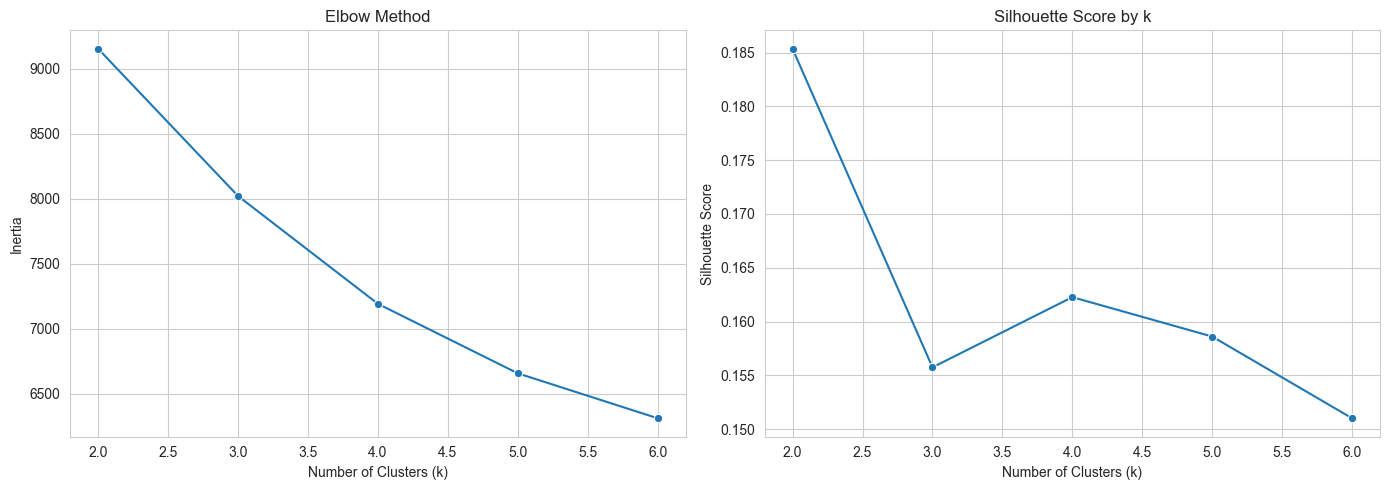

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=results_df, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=results_df, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig(plot_dir / 'cluster_selection_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Final K-Means Clustering

In [7]:
best_k = int(results_df.loc[results_df['silhouette_score'].idxmax(), 'k'])
best_silhouette = results_df['silhouette_score'].max()

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f'Selected number of clusters: {best_k}')
print(f'Silhouette score: {best_silhouette:.4f}')
display(df_clustered.head())

Selected number of clusters: 2
Silhouette score: 0.1854


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,1


## 6. Cluster Analysis

In [8]:
cluster_counts = df_clustered['cluster'].value_counts().sort_index()
display(cluster_counts.to_frame(name='count'))

,count
cluster,
0,401
1,618


In [9]:
quality_cluster_table = pd.crosstab(df_clustered['cluster'], df_clustered['quality'])
display(quality_cluster_table)

quality,3,4,5,6,7,8
cluster,,,,,,
0,1,7,122,178,84,9
1,2,26,312,245,31,2


In [10]:
cluster_profile = df_clustered.groupby('cluster').mean(numeric_only=True)
display(cluster_profile)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,
0,9.459352,0.402756,0.425860,2.321945,0.079504,14.137157,39.249377,0.997149,3.242020,0.684539,10.680133,5.907731
1,7.333172,0.600210,0.137217,2.118932,0.077770,15.493528,44.425566,0.996156,3.374531,0.596650,10.195092,5.457929


## 7. Cluster Visualization

 - PCA 

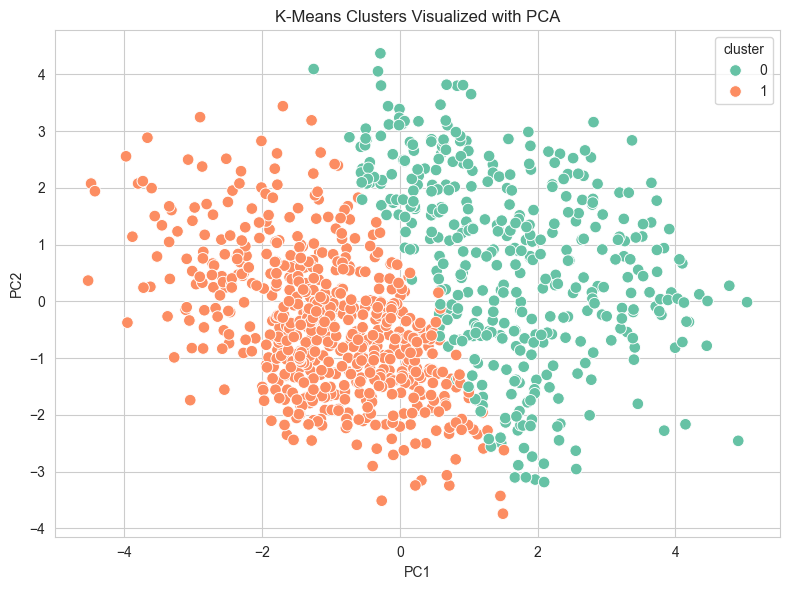

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='Set2', s=70)
plt.title('K-Means Clusters Visualized with PCA')
plt.tight_layout()
plt.savefig(plot_dir / 'kmeans_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Clustered Dataset

In [12]:
output_path = Path('../data/processed/winequality_clustered.csv')
df_clustered.to_csv(output_path, index=False)

print(f'Clustered dataset saved to: {output_path}')

Clustered dataset saved to: ..\data\processed\winequality_clustered.csv
